In [ ]:
# !pip install pyreadstat

In [1]:
import pyreadstat
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
from collections import Counter
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Recall
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from keras_tuner import HyperModel, RandomSearch
import keras_tuner as kt
from tensorflow.keras import regularizers
from tensorflow.keras.metrics import Recall


In [2]:
import os
import random
import numpy as np
import tensorflow as tf

def set_seed(seed=42):
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)         # Python hash seed
    random.seed(seed)                                # Python random module
    np.random.seed(seed)                             # NumPy
    tf.random.set_seed(seed)                         # TensorFlow
    tf.keras.utils.set_random_seed(seed)             # For keras randomness
    tf.config.experimental.enable_op_determinism()   # Make ops deterministic

# Call this before training
set_seed(42)


# EDA

In [4]:
# df_ch = pyreadstat.read_sav('/kaggle/input/malnutrition/ch.sav')[0]
# data = pd.read_spss('/kaggle/input/malnutrition/ch.sav')

df_ch = pyreadstat.read_sav(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")[0]
# Renaming the columns
df1 = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = df1.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df2 = df1.copy()
df2.dropna(inplace=True)

df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({1: 1, 2: 0})
df2.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,7.8,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
2,2.0,11.1,1.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0


In [ ]:
# Standardize continuous column
scaler = StandardScaler()
df2['child_weight'] = scaler.fit_transform(df2[['child_weight']])

# One-hot encode nominal categorical column
df2 = pd.get_dummies(df2, columns=['province'], drop_first=True)

# Convert only boolean dummy columns to 0/1
cols_to_convert = df2.columns.difference(['child_weight'])
df2[cols_to_convert] = df2[cols_to_convert].astype(int)

df2.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-0.617934,1,0,0,0,1,5,0,1,1,0,0,0,0,0,0
2,2,0.797956,1,1,0,0,0,2,0,1,0,0,0,0,0,0,0


In [ ]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Further split 80% train into 70% train + 10% val
# We want 15% of total data as validation, which is 15 / 80 = 0.1875 of the temp set
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1875, stratify=y_temp, random_state=42)

# Artificial Neural Network

In [ ]:
# Define model architecture
model_simple = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
])

# Compile model
model_simple.compile(
    optimizer=Adam(learning_rate=0.005),
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall']
)

# Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = model_simple.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    shuffle=True,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6154 - loss: 0.6766 - recall: 0.4158 - val_accuracy: 0.6555 - val_loss: 0.6304 - val_recall: 0.5314
Epoch 2/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6750 - loss: 0.6182 - recall: 0.5222 - val_accuracy: 0.6853 - val_loss: 0.5945 - val_recall: 0.7531
Epoch 3/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6828 - loss: 0.6077 - recall: 0.5486 - val_accuracy: 0.7132 - val_loss: 0.5800 - val_recall: 0.6653
Epoch 4/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6956 - loss: 0.5891 - recall: 0.5430 - val_accuracy: 0.7356 - val_loss: 0.5737 - val_recall: 0.6444
Epoch 5/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7067 - loss: 0.5828 - recall: 0.5640 - val_accuracy: 0.7374 - val_loss: 0.5557 - val_recall: 0.6402
Epoch 6/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7075 - loss: 0.5698 - recall: 0.5538 - val_accuracy: 0.7374 - val_loss: 0.5662 - val_recall: 0.644

### For better accuracy but has less recall

In [ ]:
# # Define model architecture
# model_simple = Sequential([
#     Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
#     Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dropout(0.2),
#     Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
# ])

# # Compile model
# model_simple.compile(
#     optimizer=Adam(learning_rate=0.005),
#     loss='binary_crossentropy',
#     metrics=['accuracy', 'recall']
# )

# # Early stopping to avoid overfitting
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # Fit the model
# history = model_simple.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     shuffle=True,
#     epochs=100,
#     batch_size=16,
#     callbacks=[early_stop],
#     verbose=1
# )

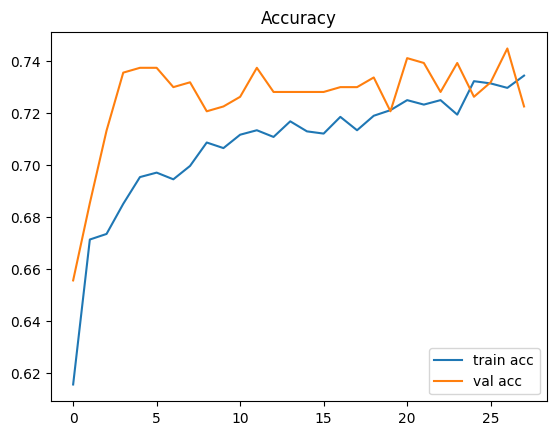

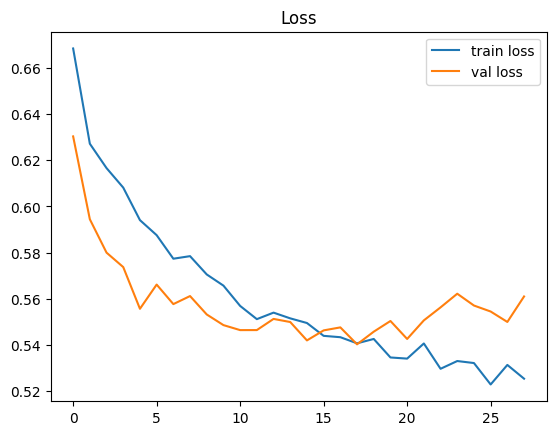

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')

# Loss
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()


In [ ]:
y_probs = model_simple.predict(X_test)
y_probs = (y_probs > 0.5).astype("int")

print(classification_report(y_test, y_probs))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       0.71      0.80      0.75       397
           1       0.71      0.58      0.64       320

    accuracy                           0.71       717
   macro avg       0.71      0.69      0.70       717
weighted avg       0.71      0.71      0.70       717



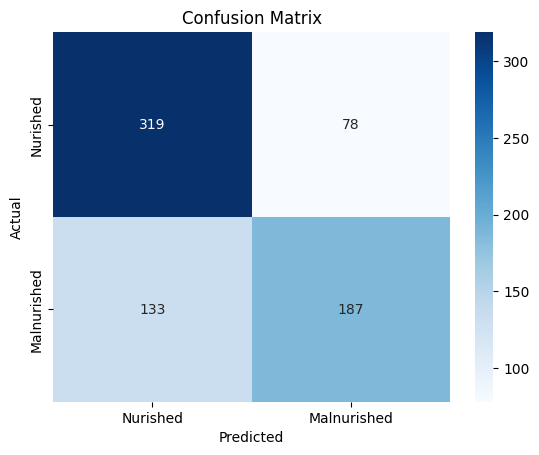

In [ ]:
cm = confusion_matrix(y_test, y_probs)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Use model.predict() and flatten to 1D
y_probas = model_simple.predict(X_test).ravel()

# Compute Average Precision Score
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Average Precision: 0.7566134718646733


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


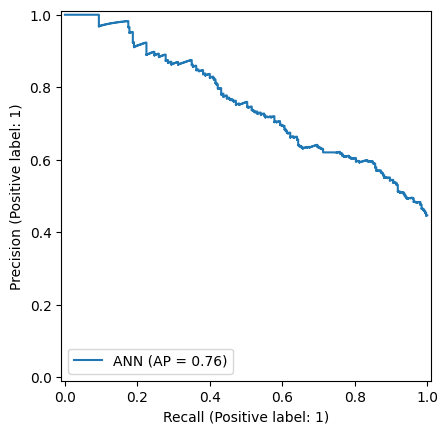

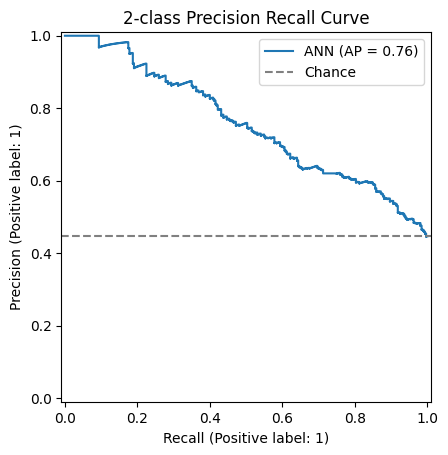

In [ ]:
# Get predicted probabilities
y_probas = model_simple.predict(X_test).ravel()

# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probas,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()

---
# Parameter Tunned

In [ ]:
from keras_tuner import HyperModel, RandomSearch
from tensorflow.keras import regularizers

# Define a model builder function
def build_model(hp):
    model = Sequential()

    # First dense layer: tune number of neurons and dropout
    model.add(Dense(
        hp.Int('units_1', min_value=32, max_value=128, step=32),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))
    model.add(Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)))

    # Second dense layer
    model.add(Dense(
        hp.Int('units_2', min_value=16, max_value=64, step=16),
        activation='relu'
    ))
    model.add(Dropout(hp.Float('dropout_2', 0.1, 0.3, step=0.1)))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile with tunable learning rate
    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', [0.001, 0.0005, 0.005])),
        loss='binary_crossentropy',
        metrics=['accuracy', Recall()]
    )

    return model

In [ ]:
import keras_tuner as kt

# Define tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_recall',  # Focus on recall
    max_trials=10,
    executions_per_trial=1,
    overwrite=True,
    directory='kt_dir',
    project_name='malnutrition_tuning'
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Run the search
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Trial 10 Complete [00h 00m 08s]
val_recall: 0.7112970948219299

Best val_recall So Far: 0.7489539980888367
Total elapsed time: 00h 02m 17s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters:")
print(f"units_1: {best_hps.get('units_1')}")
print(f"dropout_1: {best_hps.get('dropout_1')}")
print(f"units_2: {best_hps.get('units_2')}")
print(f"dropout_2: {best_hps.get('dropout_2')}")
print(f"learning_rate: {best_hps.get('learning_rate')}")


Best Hyperparameters:
units_1: 96
dropout_1: 0.4
units_2: 32
dropout_2: 0.1
learning_rate: 0.0005


C:\Users\dbastola2022\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\dbastola2022\AppData\Roaming\Python\Python310\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
test_loss, test_acc, test_recall = best_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Recall: {test_recall:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6420 - loss: 0.6415 - recall: 0.7353  
Test Accuracy: 0.6499
Test Recall: 0.7625


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[[222 175]
 [ 76 244]]


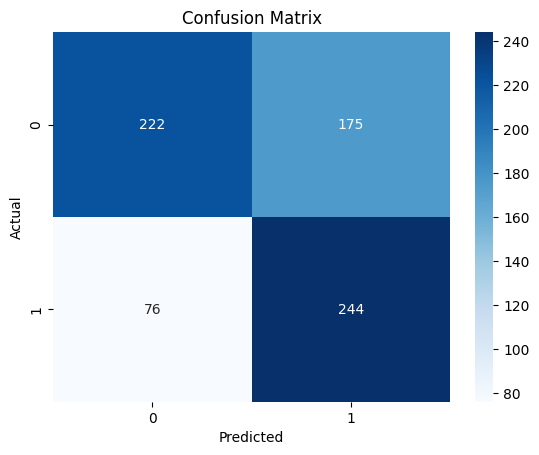

In [ ]:
# Predict classes
y_prob = best_model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).reshape(-1)

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
y_probs = best_model.predict(X_test)
y_probs = (y_probs > 0.5).astype("int")

print(classification_report(y_test, y_probs))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.74      0.56      0.64       397
           1       0.58      0.76      0.66       320

    accuracy                           0.65       717
   macro avg       0.66      0.66      0.65       717
weighted avg       0.67      0.65      0.65       717



23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


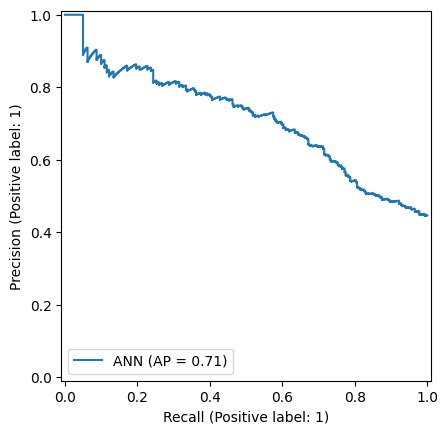

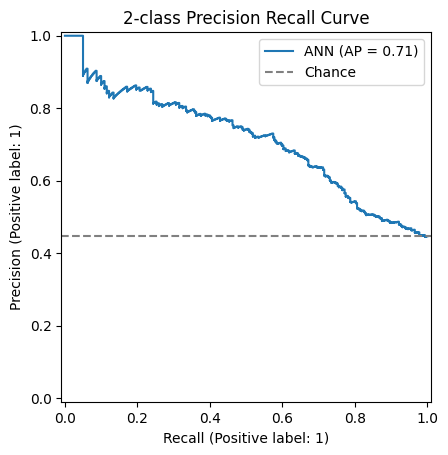

In [ ]:
# Get predicted probabilities
y_probas = best_model.predict(X_test).ravel()

# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probas,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()